In [1]:
import os, sys
import numpy as np
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import anndata
from tqdm.autonotebook import tqdm
 
    

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: 

In [2]:
# CATEGORY="test13"
# sc.tl.rank_genes_groups(adata_all, CATEGORY, method='t-test', key_added="de_leiden");
# df2 = pd.DataFrame(adata_all.uns['de_leiden']['names'])
# F6_top2000= df2["F6: Inflammatory myofibroblast"][:2000]



In [3]:
# F6_top500= df2["F6: Inflammatory myofibroblast"][:500]
# import pickle
# from pathlib import Path

# out = Path("/nfs/team298/ls34/dicts/f6_top500genes.pkl")

# with open(out, "wb") as f:
#     pickle.dump(F6_top500, f, protocol=pickle.HIGHEST_PROTOCOL)

In [4]:
# F6_top200= df2["F6: Inflammatory myofibroblast"][:200]
# import pickle
# from pathlib import Path

# out = Path("/nfs/team298/ls34/dicts/f6_top200genes.pkl")

# with open(out, "wb") as f:
#     pickle.dump(F6_top200, f, protocol=pickle.HIGHEST_PROTOCOL)

In [5]:
# import pickle
# from pathlib import Path

# out = Path("/nfs/team298/ls34/dicts/f6_top2000genes.pkl")

# with open(out, "wb") as f:
#     pickle.dump(F6_top2000, f, protocol=pickle.HIGHEST_PROTOCOL)

In [6]:
# 9

In [7]:
sc.settings.set_figure_params(dpi=100,
                              dpi_save=300,
                                  facecolor="none",   # transparent
                              frameon=False, 
                              figsize=(12, 12))


# LOAD INTRINSIC

In [8]:
adata_intrinsic=sc.read_h5ad('/nfs/team361/ls34/inflow/adata_hs_intrinsic_v4_f6.h5ad')
#adata_intrinsic=adata_intrinsic[adata_intrinsic.obs["fine_annotation"].str.startswith("F6")].copy()
import gc
gc.collect()
adata_intrinsic.write('/nfs/team361/ls34/inflow/adata_hs_intrinsic_v4_f6.h5ad')



In [9]:
# adata_intrinsic.obs["fine_annotation"].value_counts()

In [10]:
#adata_intrinsic=adata_intrinsic[adata_intrinsic.obs["fine_annotation"].str.startswith("F6")].copy()


In [11]:
import pickle
from pathlib import Path

out = Path("./f6_leiden_new.pkl")  # current working directory
with open(out, "rb") as f:
    test = pickle.load(f)


adata_intrinsic.obs["f6"]=adata_intrinsic.obs.index.map(test)
# these labels come from F6 notebook
adata_intrinsic.obs["f6"].value_counts()




f6
TWIST2+         883
COLhi           472
TWIST2+MMP9+    322
IL11+           220
DPYD+PRDM1+     213
Name: count, dtype: int64

In [12]:
# # FILTER OUT RARE DOMAINS
# counts = adata.obs["spatial_niche"].value_counts()
# keep_niches = counts[counts >= 30].index
# adata = adata[adata.obs["spatial_niche"].isin(keep_niches)].copy()

In [13]:
# # for Xbar_int
# sc.pp.neighbors(adata_intrinsic, use_rep='MintFlow_Xbar_int')
# sc.tl.umap(adata_intrinsic, min_dist=0.2)
# sc.pl.umap(
#     adata_intrinsic,
#     color='batchID_for_MintFlow',
#     #palette=colpal,
#     show=False,
#     title='inflow Xbar_int',
#     frameon=False
# )


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'inflow Xbar_int'}, xlabel='UMAP1', ylabel='UMAP2'>

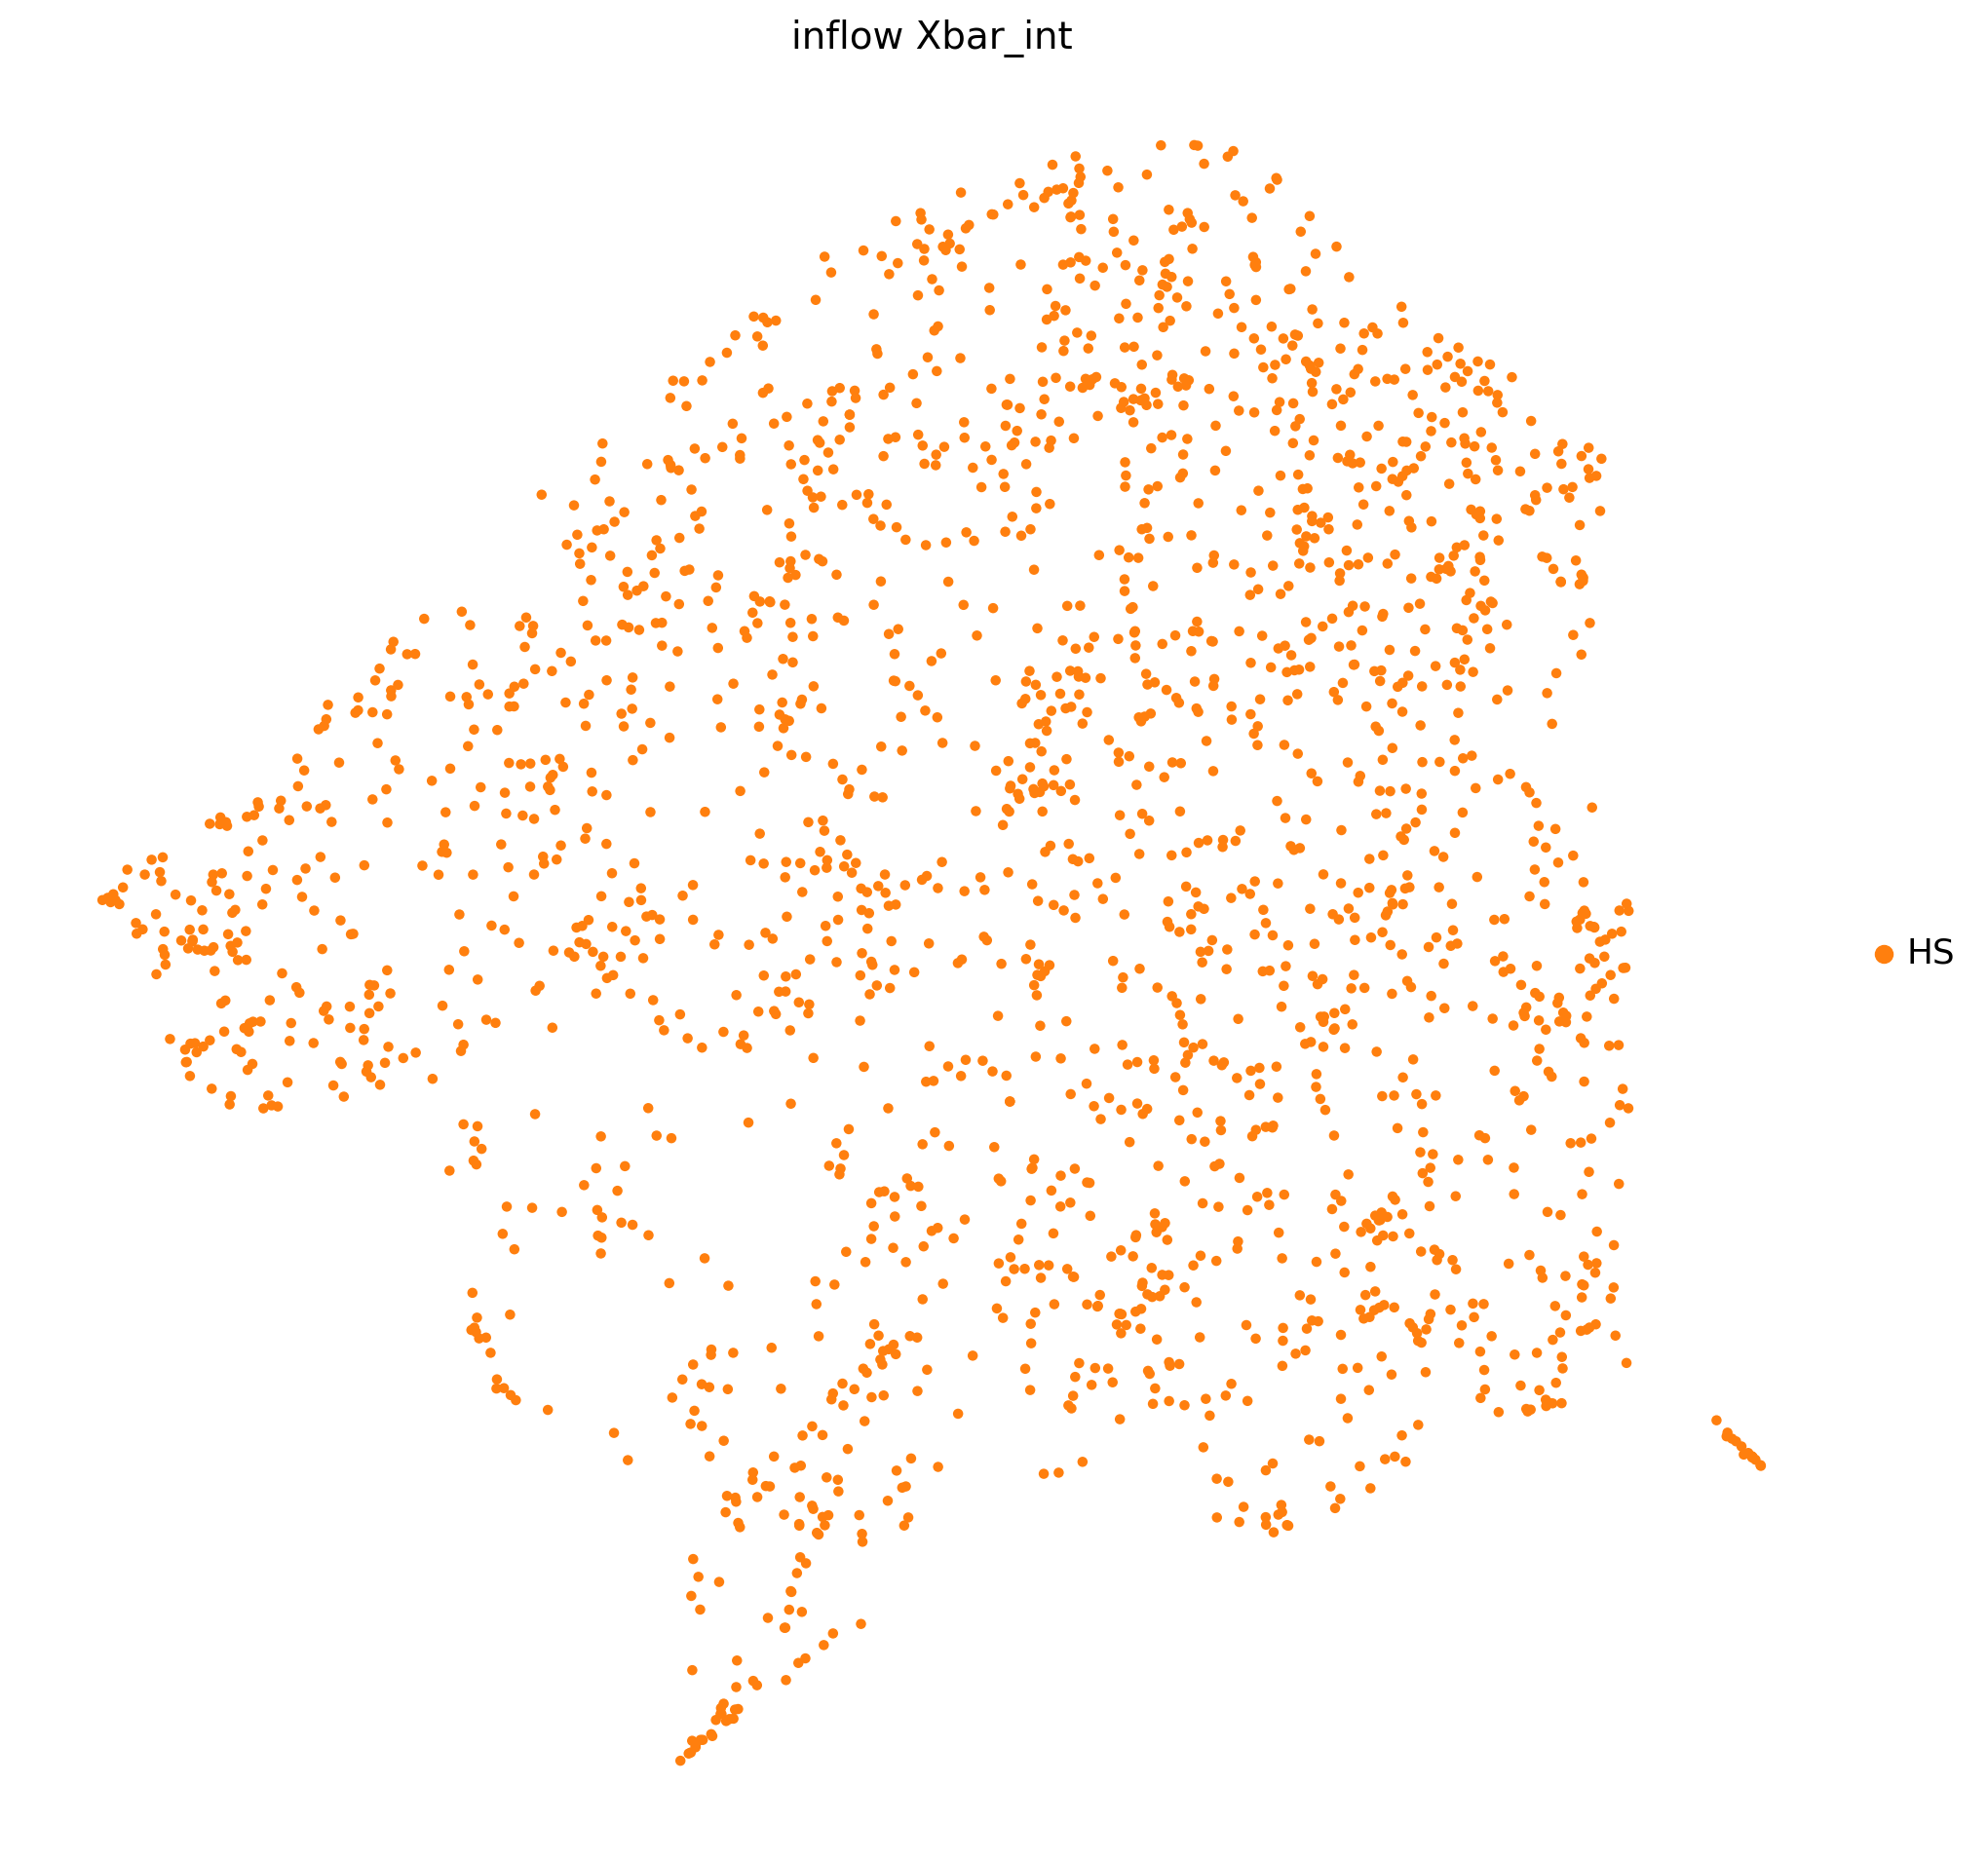

In [14]:
sc.pl.umap(
    adata_intrinsic,
    color='disease',
    #palette=colpal,
    show=False,
    title='inflow Xbar_int',
    frameon=False
)


In [15]:
# sc.pl.umap(
#     adata_intrinsic,
#     color='fine_annotation',
#     #palette=colpal,
#     show=False,
#     title='inflow Xbar_int',
#     frameon=False
# )


In [16]:
# adata_intrinsic.obs["tmp"] = adata_intrinsic.obs.index.map(md)

In [17]:
# sc.pl.umap(
#     adata_intrinsic,
#     color='tmp',
#     #palette=colpal,
#     show=False,
#     title='inflow Xbar_int',
#     frameon=False,
#     palette=colors,
# )


In [18]:
# # for Xbar_int
# sc.pp.neighbors(adata, use_rep='MintFlow_Xbar_int')
# sc.tl.umap(adata, min_dist=0.2)
# sc.pl.umap(
#     adata,
#     color='batchID_for_MintFlow',
#     #palette=colpal,
#     show=False,
#     title='inflow Xbar_int',
#     frameon=False
# )

In [19]:
# RES=0.5
# sc.tl.leiden(adata, #restrict_to=(CATEGORY,subset_cluster), 
#              resolution=RES, random_state=1, key_added=f'leiden_res{RES}') #neighbors_key='neighbor_30')

# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(12, 12))
# sc.pl.umap(adata,  
#            color=[f'fine_annotation',],
#            s=20,
#            legend_loc="on data",
#            legend_fontsize=8)




In [20]:

# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(12, 12))
# sc.pl.umap(adata,  
#            color=[f'leiden_res{RES}', "fine_annotation"],
#            s=20,
#            legend_loc="on data",
#            legend_fontsize=8)




In [21]:
# adata.write('/nfs/team361/ls34/inflow/adata_hs_intrinsic_v2_T.h5ad')

In [22]:
# srop

In [23]:
# sc.pp.neighbors(adata, use_rep='MintFlow_Xbar_mic')


In [24]:
# # for Xbar_spl
# sc.tl.umap(adata, min_dist=0.1)
# sc.pl.umap(
#     adata,
#     color='batchID_for_MintFlow',
#     #palette=colpal,
#     show=False,
#     title='inflow Xbar_spl',
#     frameon=False
# )

In [25]:
# # for Xbar_spl
# sc.tl.umap(adata, min_dist=0.2)
# sc.pl.umap(
#     adata,
#     color='disease',
#     #palette=colpal,
#     show=False,
#     title='inflow Xbar_spl',
#     frameon=False
# )

In [26]:
# colors2 = {
#     "DPYD+PRDM1+": "#40E0D0",  # turquoise
#     "COLhi": "#FF9F00",       # pastel pink
#     "TWIST2+": "#E41A1C",     # red
#     "TWIST2+MMP9+": "#FF66CC",       # neon green
#     "IL11+": "#377EB8",       # blue
#     "NA": "#D3D3D3",          # light grey
# }

# colors2 = {
#     "DPYD+PRDM1+": "#40E0D0",  # turquoise
#     "COLhi": "#FF9F00",       # pastel pink
#     "TWIST2+": "#E41A1C",     # red
#     "TWIST2+MMP9+": "#FF66CC",       # neon green
#     "IL11+": "#377EB8",       # blue
#     "NA": "#D3D3D3",          # light grey
# }



colors2 = {
    "DPYD+PRDM1+": "#40E0D0",  # turquoise
    "COLhi": "#5FAF3A",       # pastel pink
    "TWIST2+": "#E41A1C",     # red
    "TWIST2+MMP9+": "#FF66CC",       # neon green
    "IL11+": "#377EB8",       # blue
    "NA": "#D3D3D3",          # light grey
}



/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


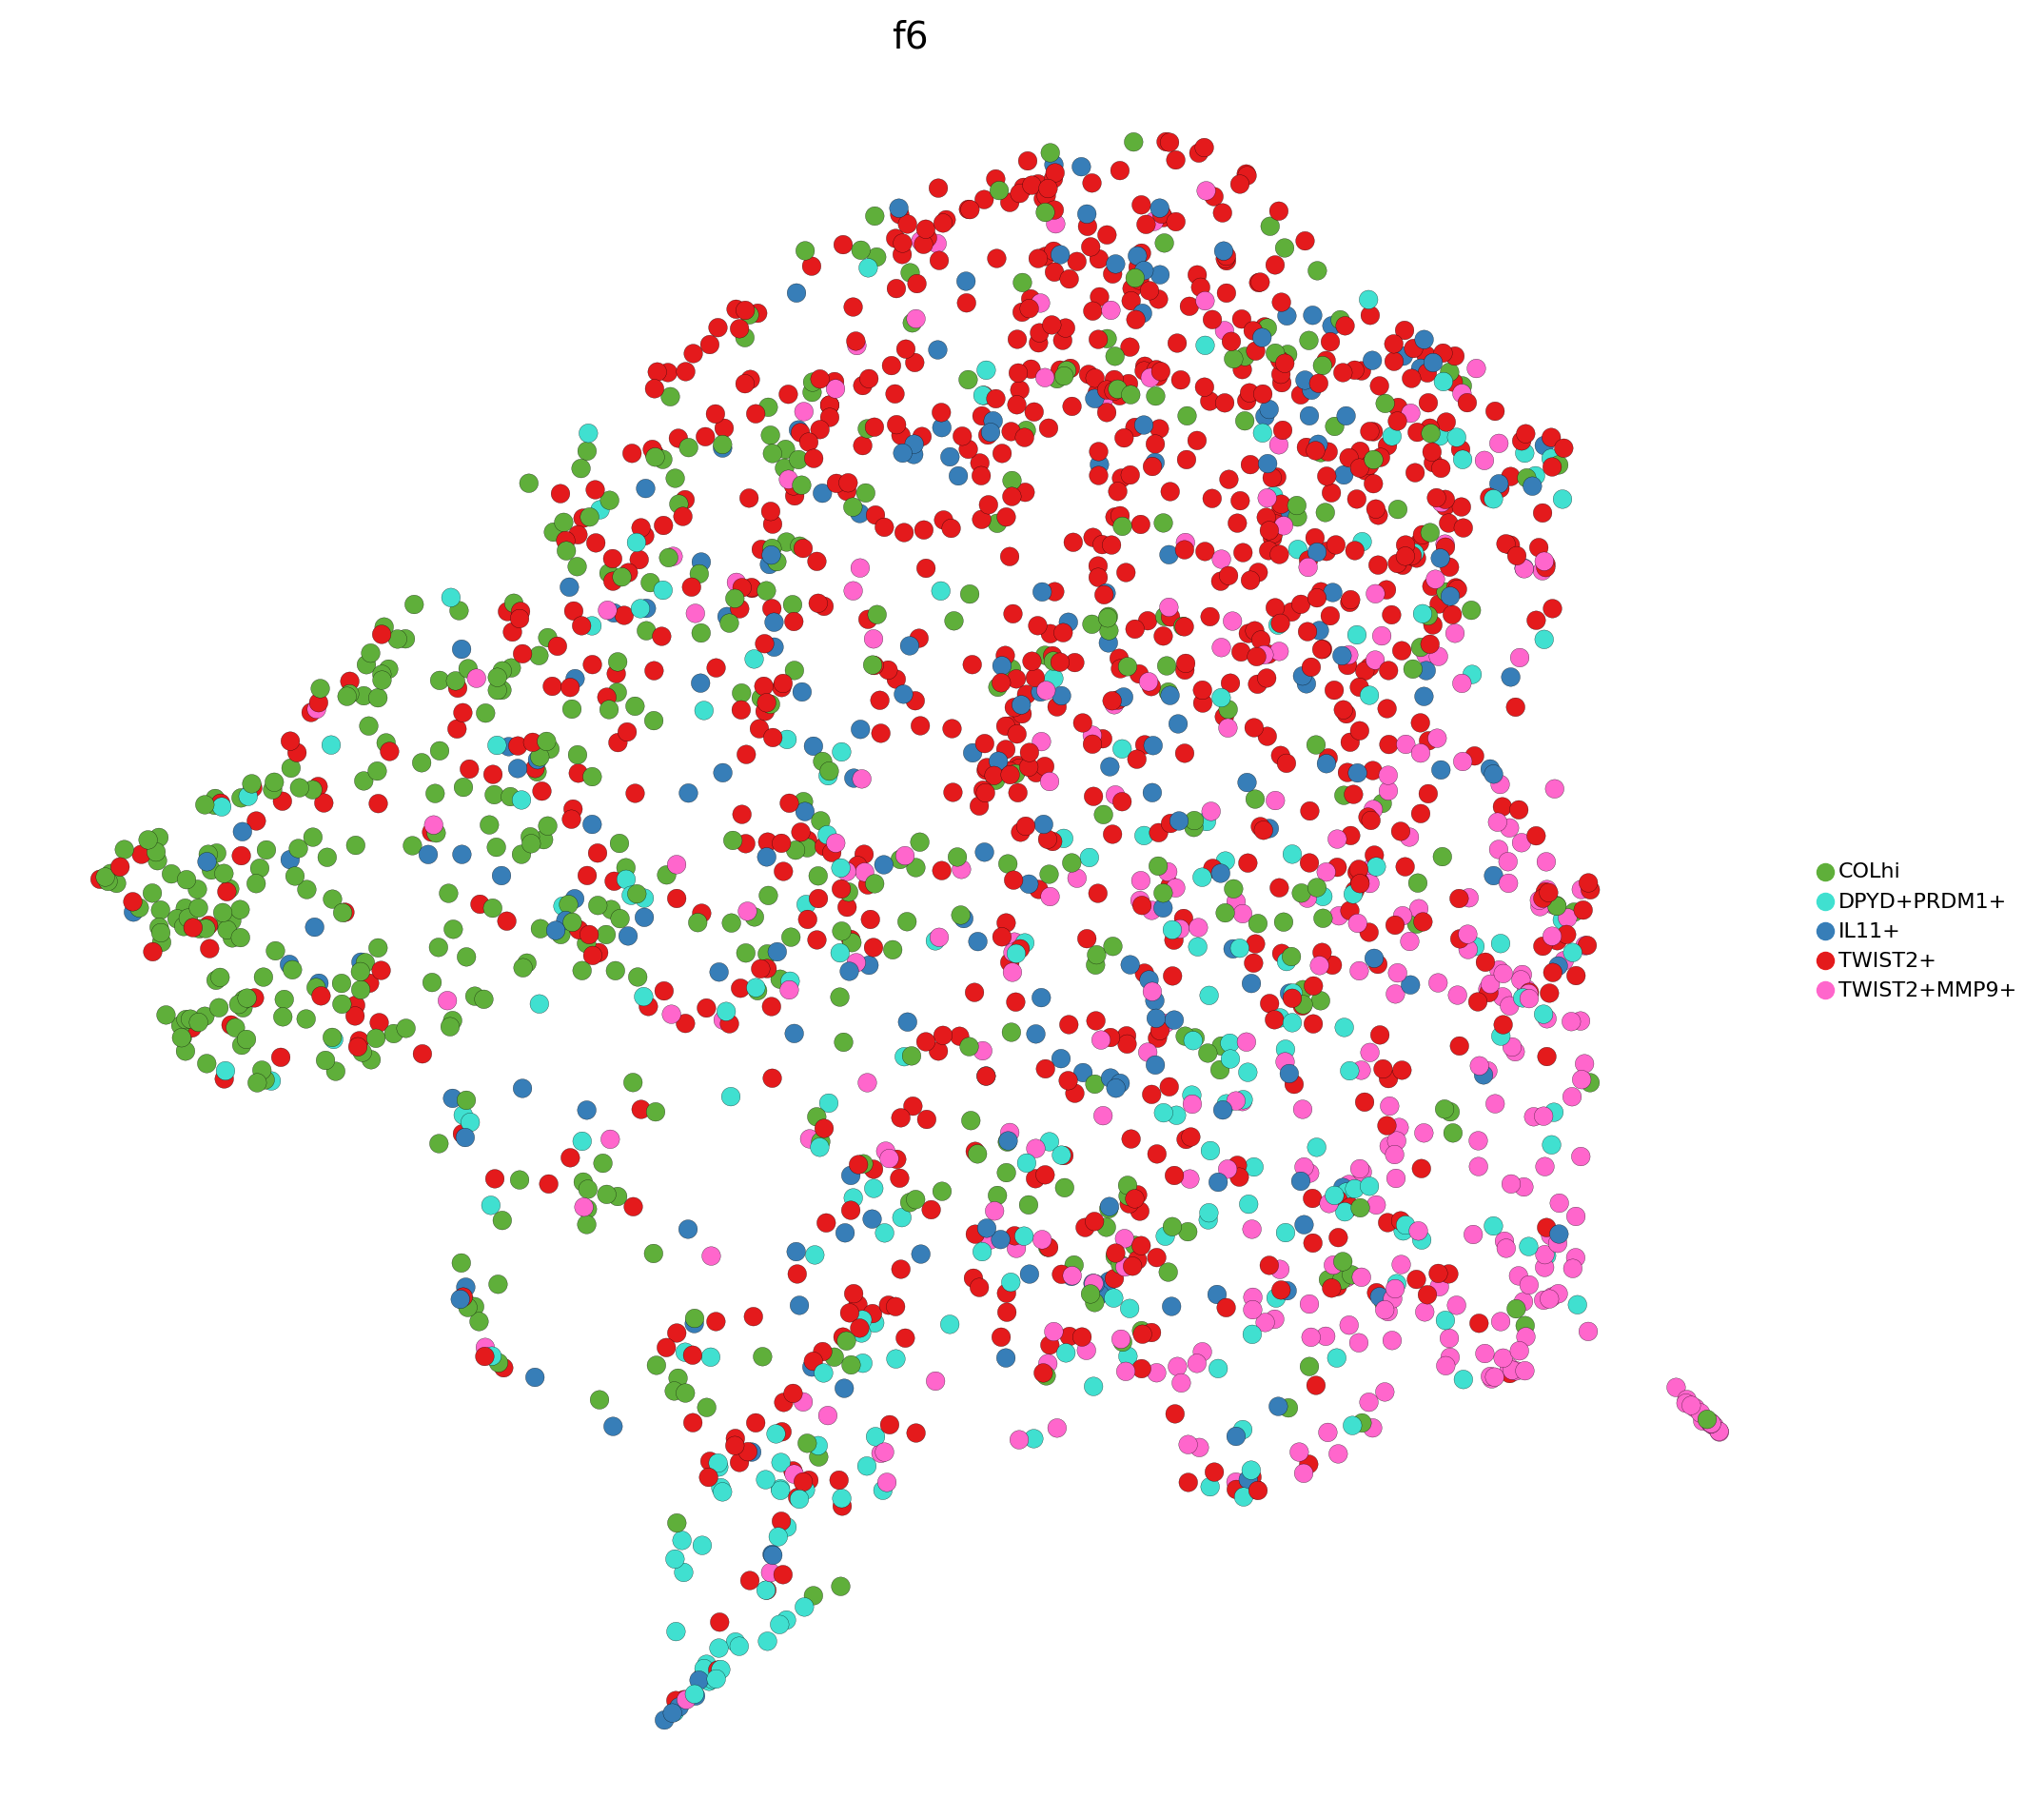

In [27]:
RES=1
sc.pl.umap(adata_intrinsic,  
           color=[ "f6"],
           s=200,
           #legend_loc="on data",
           legend_fontsize=8,
          edgecolor='black',
           linewidth=0.1,
           palette=colors2,
           save="f6_intrinsic_umap.pdf"
          )




In [28]:
adata=sc.read_h5ad('/nfs/team361/ls34/inflow/adata_hs_extrinsic_v4_f6.h5ad')

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


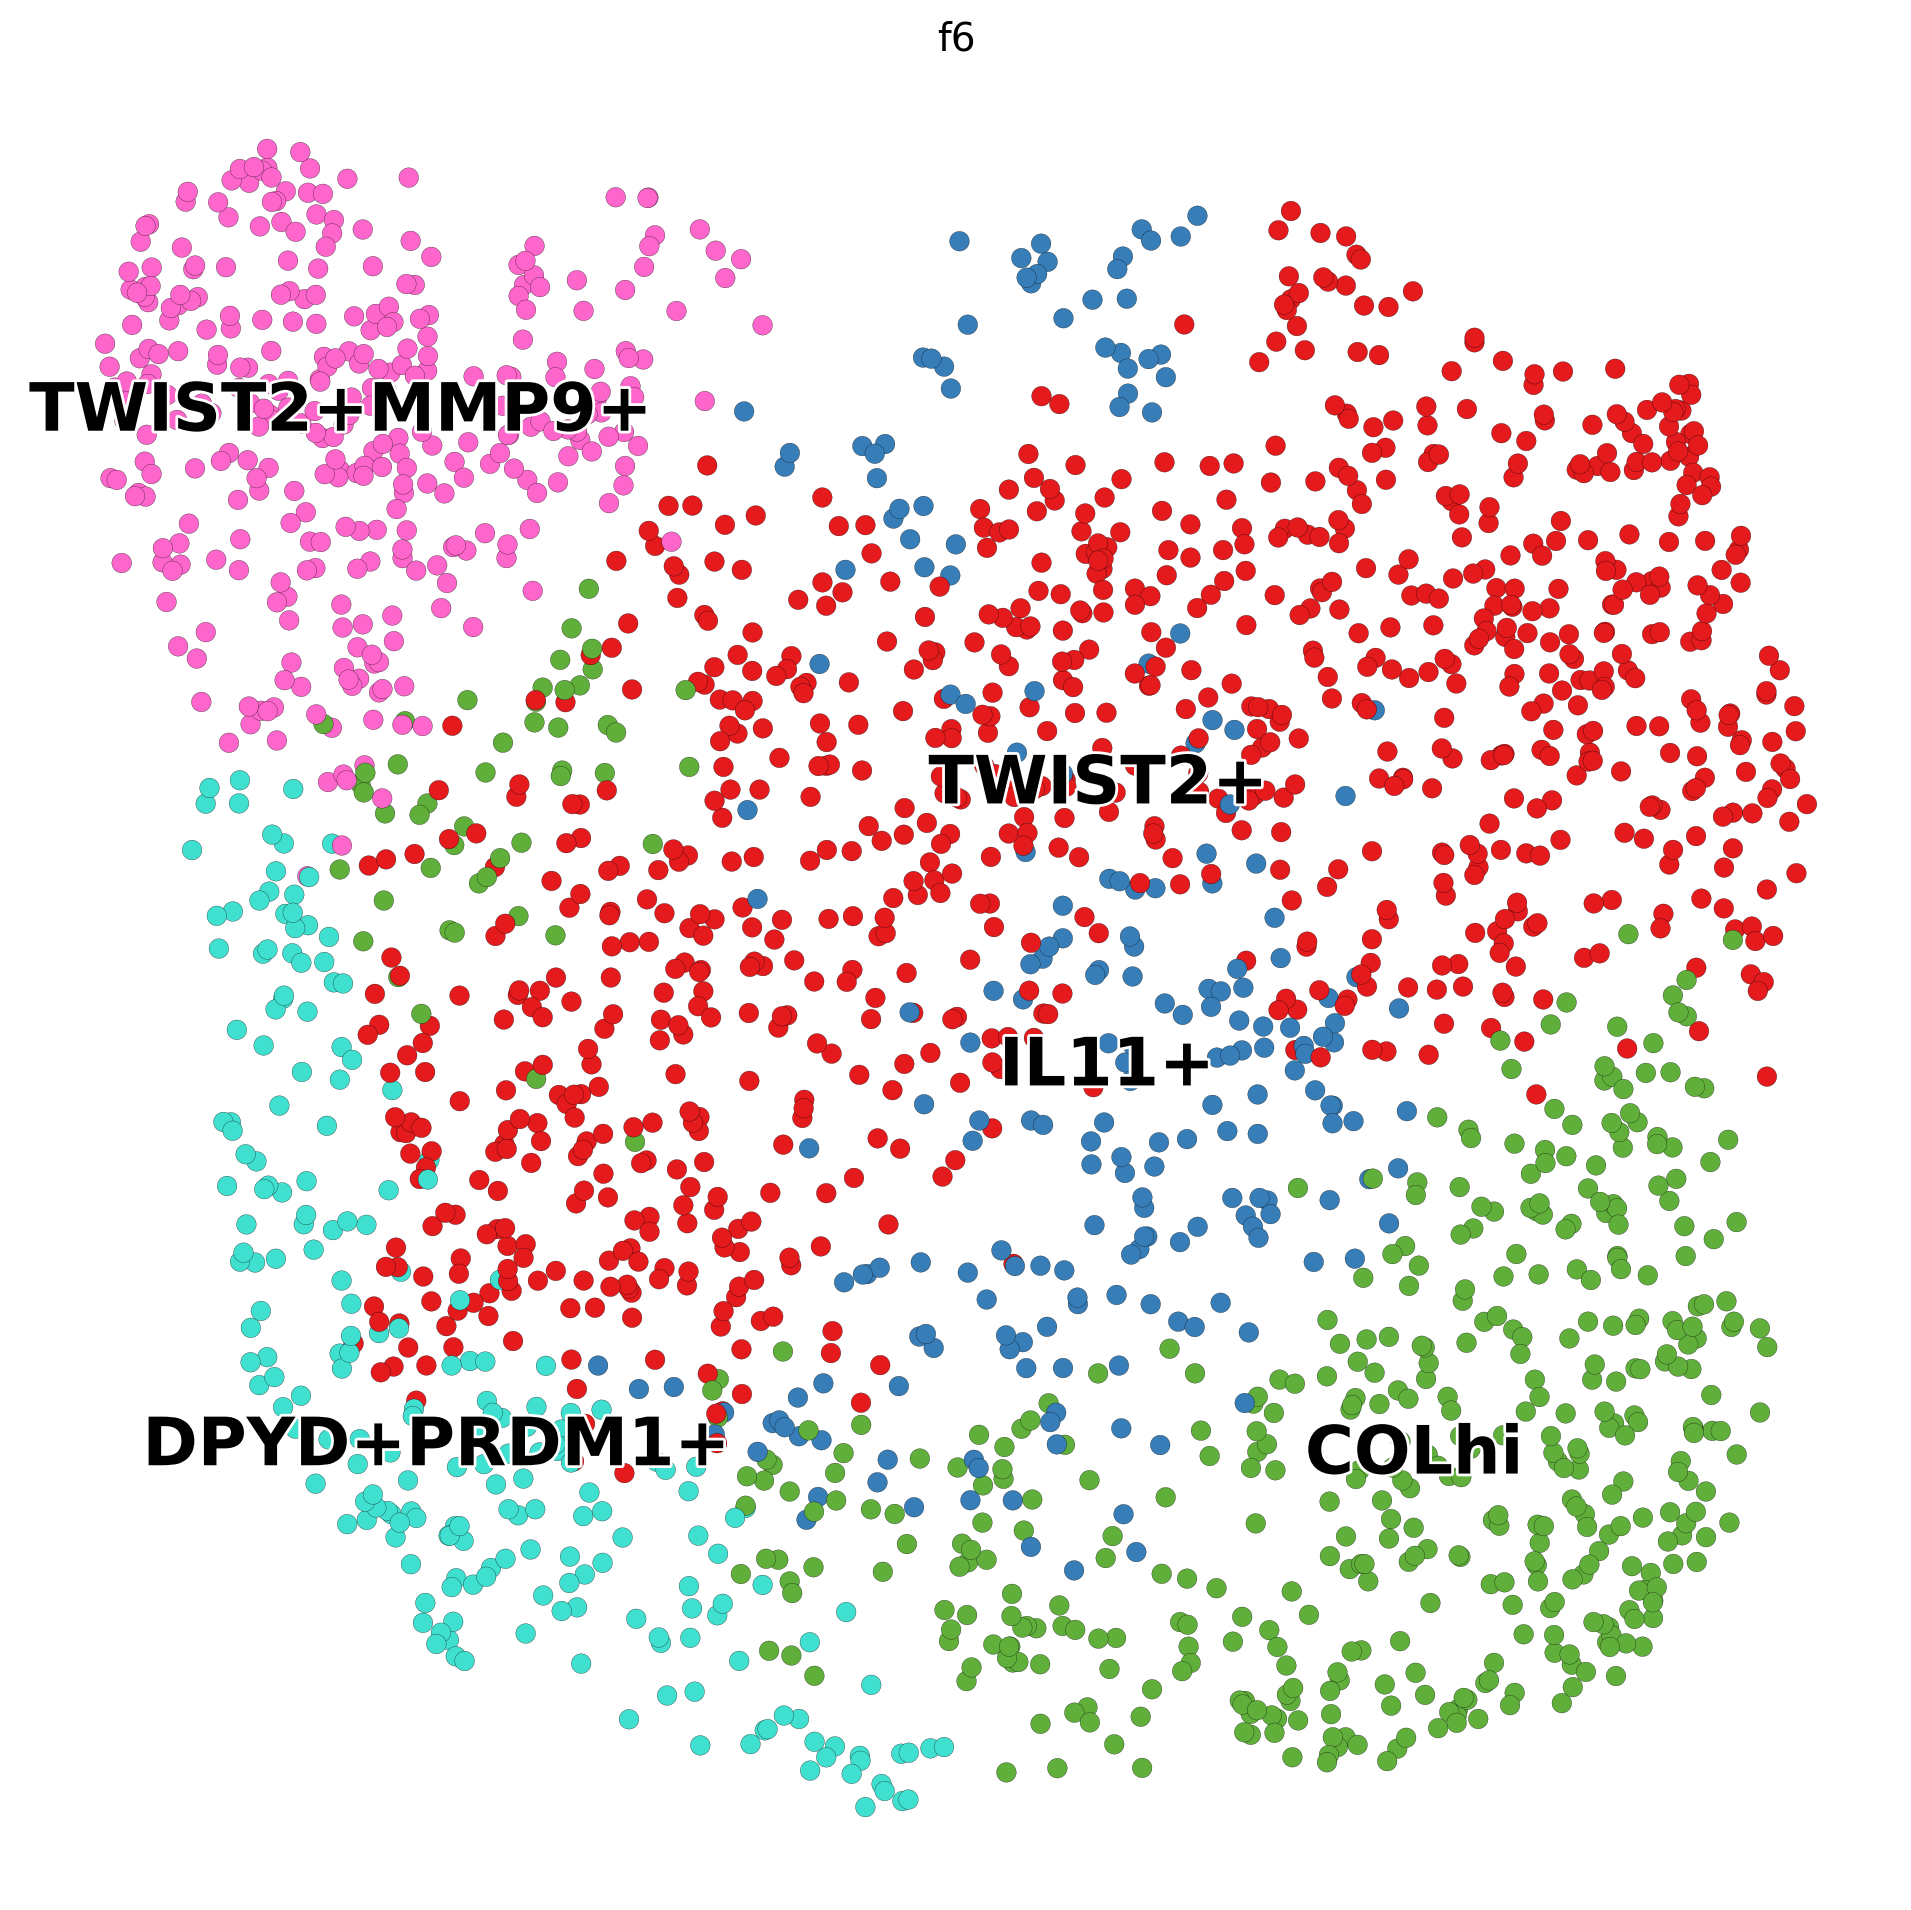

In [29]:
RES=1

sc.pl.umap(adata,  
           color=[ "f6"],
           s=200,
           legend_loc="on data",
           legend_fontsize=24,
                      legend_fontoutline=2,

          edgecolor='black',
           linewidth=0.1,
           palette=colors2,
                      save="f6_extrinsic_umap.pdf",
           

          )






In [30]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
#adata.layers["normalized"] = adata.X.co




/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


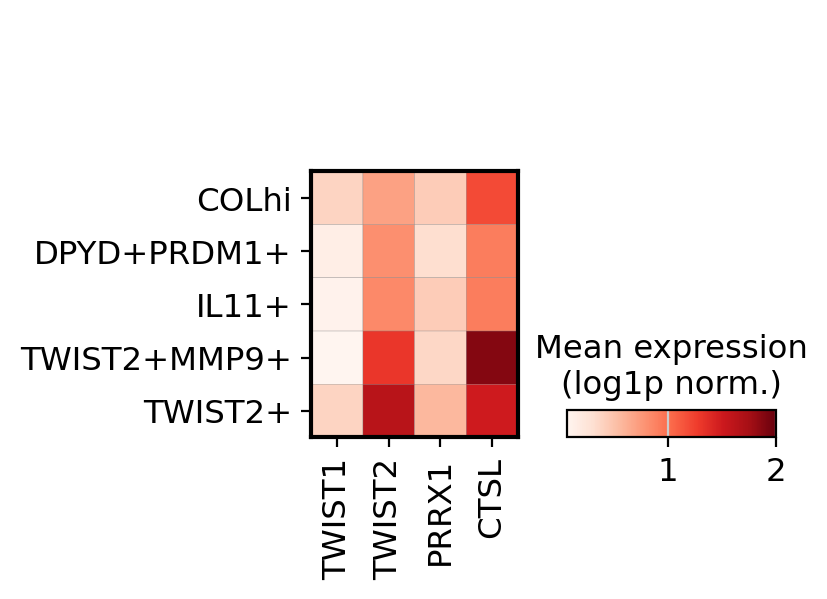

In [31]:
sc.pl.matrixplot(
        adata,
        ["TWIST1", "TWIST2", "PRRX1",  "CTSL"],
        groupby="f6",
        #standard_scale="var",
        dendrogram=False,
    cmap="Reds",
    vmax=2,
        colorbar_title="Mean expression\n(log1p norm.)",

        categories_order=['COLhi', 'DPYD+PRDM1+', 'IL11+', 'TWIST2+MMP9+', 'TWIST2+', ],
    save="hs_lo.pdf"

    #save="eczema_mcps.pdf"
    )






/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


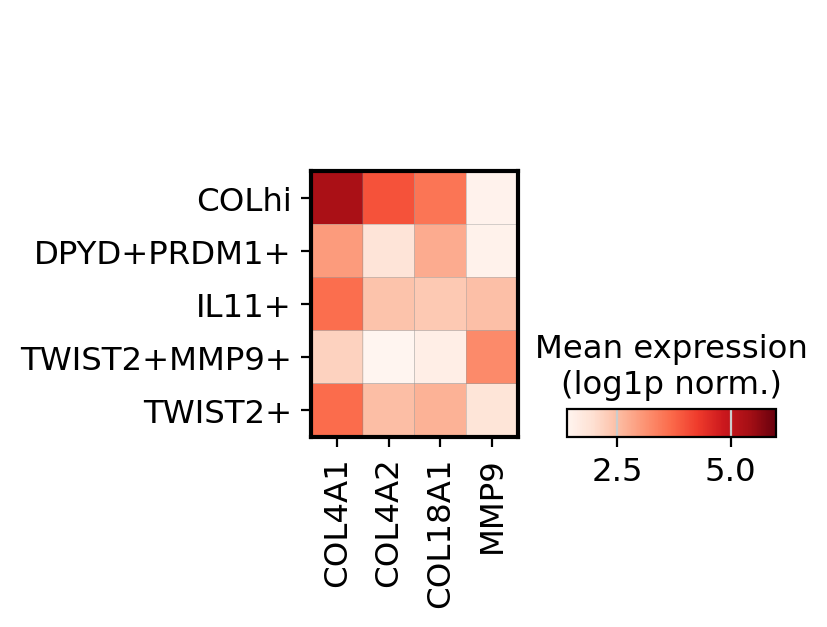

In [32]:
sc.pl.matrixplot(
        adata,
        ["COL4A1", "COL4A2", "COL18A1", "MMP9",],
        groupby="f6",
        #standard_scale="var",
        dendrogram=False,
    cmap="Reds",
    vmax=6,
    colorbar_title="Mean expression\n(log1p norm.)",
        categories_order=['COLhi', 'DPYD+PRDM1+', 'IL11+', 'TWIST2+MMP9+', 'TWIST2+', ],

    save="hs_high.pdf"
    )












/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


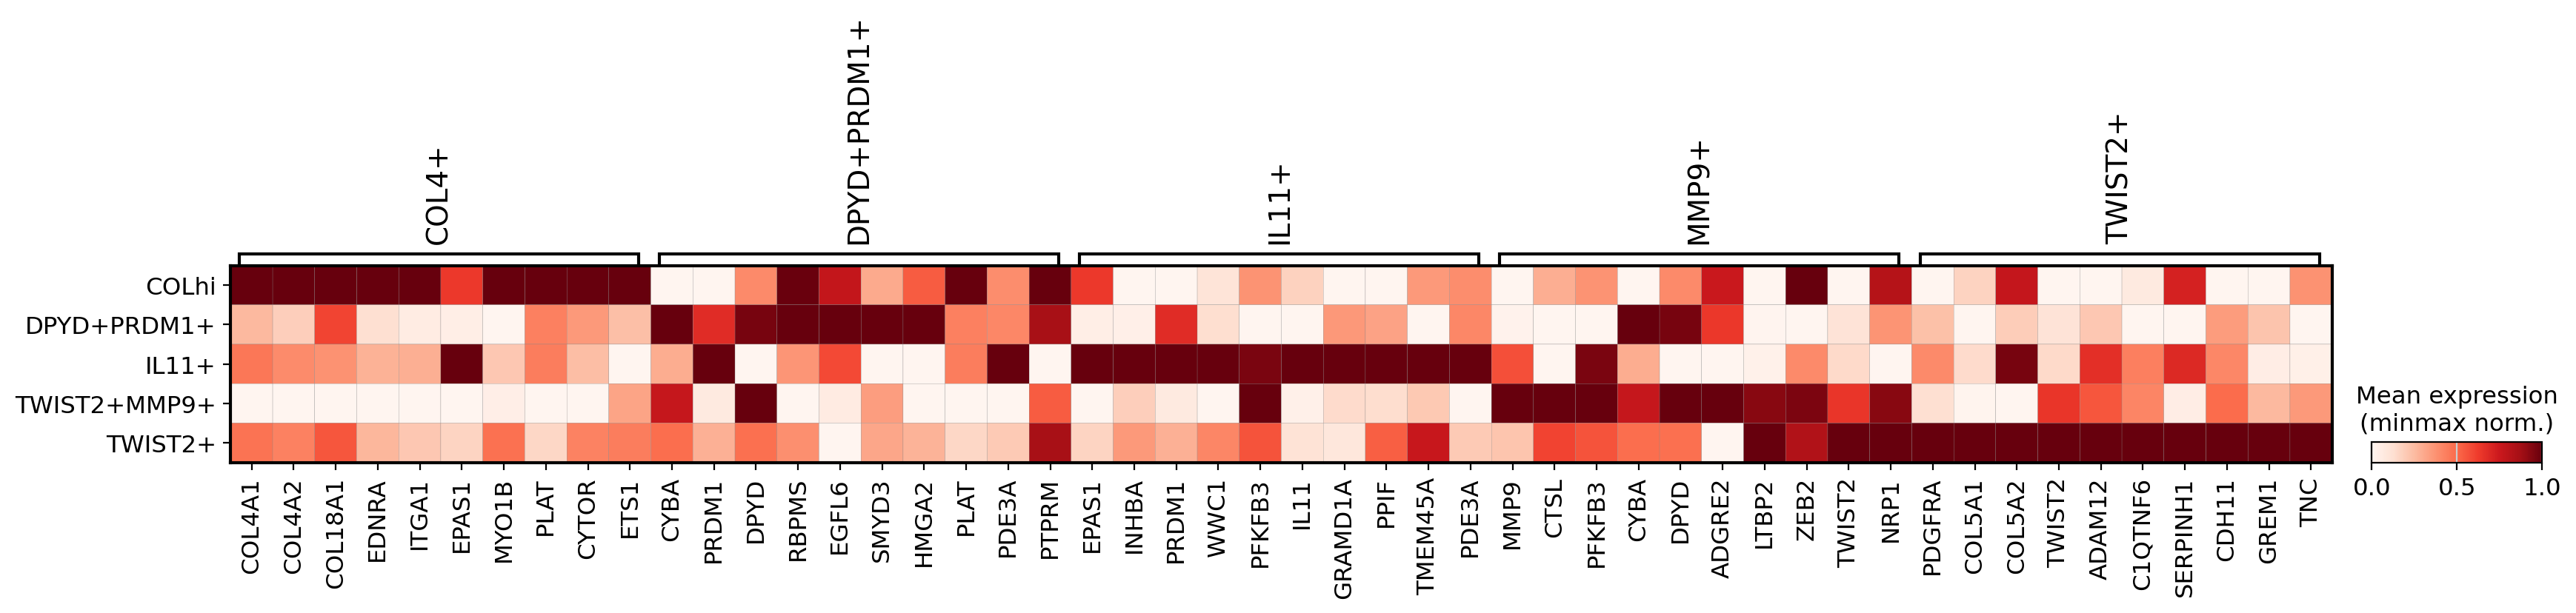

In [33]:
RESULTS_DI = {'COL4+': ['COL4A1',
  'COL4A2',
  'COL18A1',
  'EDNRA',
  'ITGA1',
  'EPAS1',
  'MYO1B',
  'PLAT',
  'CYTOR',
  'ETS1'],
 'DPYD+PRDM1+': ['CYBA',
  'PRDM1',
  'DPYD',
  'RBPMS',
  'EGFL6',
  'SMYD3',
  'HMGA2',
  'PLAT',
  'PDE3A',
  'PTPRM'],
 'IL11+': ['EPAS1',
  'INHBA',
  'PRDM1',
  'WWC1',
  'PFKFB3',
  'IL11',
  'GRAMD1A',
  'PPIF',
  'TMEM45A',
  'PDE3A'],
 'MMP9+': ['MMP9',
  'CTSL',
  'PFKFB3',
  'CYBA',
  'DPYD',
  'ADGRE2',
  'LTBP2',
  'ZEB2',
  'TWIST2',
  'NRP1'],
 'TWIST2+': ['PDGFRA',
  'COL5A1',
  'COL5A2',
  'TWIST2',
  'ADAM12',
  'C1QTNF6',
  'SERPINH1',
  'CDH11',
  'GREM1',
  'TNC']}

sc.pl.matrixplot(
        adata,
        RESULTS_DI,
        groupby="f6",
        standard_scale="var",
        dendrogram=False,
    cmap="Reds",
    vmax=1,
    categories_order=['COLhi', 'DPYD+PRDM1+', 'IL11+', 'TWIST2+MMP9+', 'TWIST2+', ],

    save="hs_dotplot_all.pdf",
        colorbar_title="Mean expression\n(minmax norm.)",

    )


In [34]:
sorted(adata.obs.f6.unique())

['COLhi', 'DPYD+PRDM1+', 'IL11+', 'TWIST2+', 'TWIST2+MMP9+']

In [35]:
# adata.X[:10,:10].A

In [36]:
# RES=1
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(12, 12))
# sc.pl.umap(adata,  
#            color=[ "f6"],
#            s=200,
#            #legend_loc="on data",
#            legend_fontsize=8,
#           edgecolor='black',
#            linewidth=0.1,
#            palette=colors2,
#           )



# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)
# #adata.layers["normalized"] = adata.X.co


# sc.pl.matrixplot(
#         adata,
#         ["TWIST1", "TWIST2", "PRRX1",  "CTSL"],
#         groupby="f6",
#         #standard_scale="var",
#         dendrogram=False,
#     cmap="Reds",
#     vmax=2,
#         categories_order=['COLhi', 'DPYD+PRDM1+', 'IL11+', 'TWIST2+MMP9+', 'TWIST2+', ]

#     #save="eczema_mcps.pdf"
#     )




# sc.pl.matrixplot(
#         adata,
#         ["COL4A1", "COL4A2", "COL18A1", "MMP9",],
#         groupby="f6",
#         #standard_scale="var",
#         dendrogram=False,
#     cmap="Reds",
#     vmax=6,
#         categories_order=['COLhi', 'DPYD+PRDM1+', 'IL11+', 'TWIST2+MMP9+', 'TWIST2+', ]

#     #save="eczema_mcps.pdf"
#     )










# RESULTS_DI = {'COL4+': ['COL4A1',
#   'COL4A2',
#   'COL18A1',
#   'EDNRA',
#   'ITGA1',
#   'EPAS1',
#   'MYO1B',
#   'PLAT',
#   'CYTOR',
#   'ETS1'],
#  'DPYD+PRDM1+': ['CYBA',
#   'PRDM1',
#   'DPYD',
#   'RBPMS',
#   'EGFL6',
#   'SMYD3',
#   'HMGA2',
#   'PLAT',
#   'PDE3A',
#   'PTPRM'],
#  'IL11+': ['EPAS1',
#   'INHBA',
#   'PRDM1',
#   'WWC1',
#   'PFKFB3',
#   'IL11',
#   'GRAMD1A',
#   'PPIF',
#   'TMEM45A',
#   'PDE3A'],
#  'MMP9+': ['MMP9',
#   'CTSL',
#   'PFKFB3',
#   'CYBA',
#   'DPYD',
#   'ADGRE2',
#   'LTBP2',
#   'ZEB2',
#   'TWIST2',
#   'NRP1'],
#  'TWIST2+': ['PDGFRA',
#   'COL5A1',
#   'COL5A2',
#   'TWIST2',
#   'ADAM12',
#   'C1QTNF6',
#   'SERPINH1',
#   'CDH11',
#   'GREM1',
#   'TNC']}

# sc.pl.matrixplot(
#         adata,
#         RESULTS_DI,
#         groupby="f6",
#         standard_scale="var",
#         dendrogram=False,
#     cmap="Reds",
#     vmax=1,
#     categories_order=['COLhi', 'DPYD+PRDM1+', 'IL11+', 'TWIST2+MMP9+', 'TWIST2+', ]

#     #save="eczema_mcps.pdf"
#     )



In [37]:
9


9

In [38]:
9

9